# Homework 3

## Your Name Here (or your names here if you are pair programming)
Cheve Garcia - gcg837

Eduardo Borges Issa - eb34276



## Normal and t distributions
## t-test


An experiment was conducted to determine the effect of children participating in a given meal preparation on calorie intake for that meal. Data are recorded below. 

Save the data to a format that can be read into python. Read the data in for analysis. Data is provided in two separted CSV files. 

* Use python to calculate the quantities and generate the visual summaries requested below. You will lose points if you are not utilizing python.

* You can use scipy libary or other libraries to do your tests or you can implement them from scratch in python 



In [1]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Question - 1
Summarize the data by whether children participated in the meal preparation or not. Use an appropriately labelled table to show the results. Also include a graphical presentation that shows the distribution of calories for participants vs. non-participants. Describe the shape of each distribution and comment on the similarity (or lack thereof) between the distributions in each population. **(2 points)**

Be aware that there is not one specific way the graph needs to look. Experiment with different types of graphs, and different parameters for the graph type. Your goal is to present the data as readable as possible. 

In [2]:
# Add your code or descriptions here 

participants = pd.read_csv("participants.csv").iloc[:, 0]
nonparticipants = pd.read_csv("nonparticipants.csv").iloc[:, 0]
p_median = participants.median()
np_median = nonparticipants.median()
summary = pd.DataFrame({"Participated": participants.describe(), "Did Not Participate": nonparticipants.describe()}).round(1)
print(summary)
print(p_median, np_median)

       Participated  Did Not Participate
count          25.0                 22.0
mean          410.1                374.1
std           121.5                133.1
min           211.0                139.7
25%           298.4                296.4
50%           424.9                374.7
75%           456.3                445.6
max           635.2                688.8
424.94 374.74


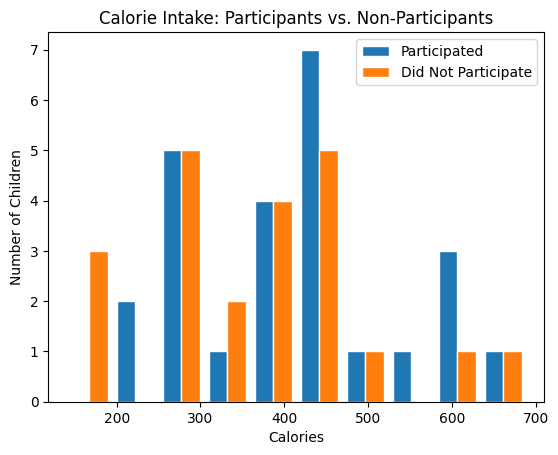

In [3]:
plt.hist([participants, nonparticipants], label=["Participated", "Did Not Participate"], edgecolor="white")
plt.xlabel("Calories")
plt.ylabel("Number of Children")
plt.title("Calorie Intake: Participants vs. Non-Participants")
plt.legend()
plt.show()

Both charts have a mild right skew and a cluster of values in the 250-500 calorie range, and a smaller portion that extends up to 700 calories. Participants are shifted slightly higher than non-participants (median 424.94 vs 374.74), and the non-participant data groups on the lower end.

# Question - 2 

Does the mean calorie consumption for those who participated in the meal preparation differ from **425**? Formally test at the $\alpha = 0.05$ level using the 5 steps outlined in the module. **(6 points)**


H0: mu = 425

H1: mu != 425

alpha = 0.05

One sample t-test

In [4]:
t_stat, p_value = stats.ttest_1samp(participants, 425)
n = len(participants)
df = n - 1
t_stat, p_value

(np.float64(-0.6139385690489593), np.float64(0.5450319510318796))

In [5]:
# step 3
t_crit = stats.t.ppf(1 - 0.05 / 2, df)
# step 4
x = abs(t_stat) > t_crit
t_crit, x

(np.float64(2.0638985616280245), np.False_)

There is not significant evidence that the mean calorie consumption for participants is different than 425. Because the calculated t-stat is less than than the t-crit value, we fail to reject the null hypothesis.

# Question -3 
Calculate a **90%** confidence interval for the mean calorie intake for participants in the meal preparation. Interpret the confidence interval. **(6 points)**

In [6]:
# Add your code or descriptions here 

se = participants.std() / np.sqrt(len(participants))

ci_90 = stats.t.interval(0.90, df=len(participants) - 1, loc=participants.mean(), scale=se)

print('90% Confidence Interval:', ci_90)

90% Confidence Interval: (np.float64(368.5004481564789), np.float64(451.658751843521))


We are 90% confident that the true population mean calorie intake for children participating in meal preparation falls between 368.50 and 451.66 calories.

# Question 4 
Formally test whether or not participants consumed 
more calories than non-participants at the $\alpha = 0.05$ level using the 5 steps procedure for hypothesis tests. **(6 points )**

In [7]:
# Add your code or descriptions here 

# Step 1:
# Hypothesis:
# H0: mu_1 - mu_2 <= 0 (Participants consumed equal to or fewer calories than non-participants)
# H1: mu_1 - mu_2 > 0 (Participants consumed more calories than non-participants — right-tailed test)
alpha = 0.05

# Step 2:
# Two-sample independent t-test
df = len(participants) + len(nonparticipants) - 2

# Step 3:
# selection criteria reject_null = t_stat > t_crit or p < alpha
t_crit = stats.t.ppf(1 - alpha, df)

# step 4:
t_stat, p_value = stats.ttest_ind(participants, nonparticipants, alternative="greater")
reject_null = t_stat > t_crit

# step 5:
reject_null, t_crit, t_stat, p_value

(np.False_,
 np.float64(1.6794273926523544),
 np.float64(0.9693504409241457),
 np.float64(0.16877591097132358))

#### Step 5: Conclusion

With alpha = 0.05 significance level, there is insufficient statistical evidence to conclude that children who participated in meal preparation consumed more calories on average than those who did not participate. We fail to reject to the null hypothesis. 